# Análisis Exploratorio y Preprocesamiento - Titanic Dataset

Proyecto individual - ED.01.02 Git, GitHub y reproducibilidad

Regina Zoé García Trejo - IDIA 222

## 1. Carga del dataset

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from preprocessing import (
    load_data, handle_missing_values, engineer_features,
    encode_categorical, scale_numeric
)

sns.set_style('whitegrid')
%matplotlib inline

df = load_data('../data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Inspección inicial

In [ ]:
print(f"Dimensiones: {df.shape}")
df.info()

Dimensiones: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

## 3. Análisis exploratorio

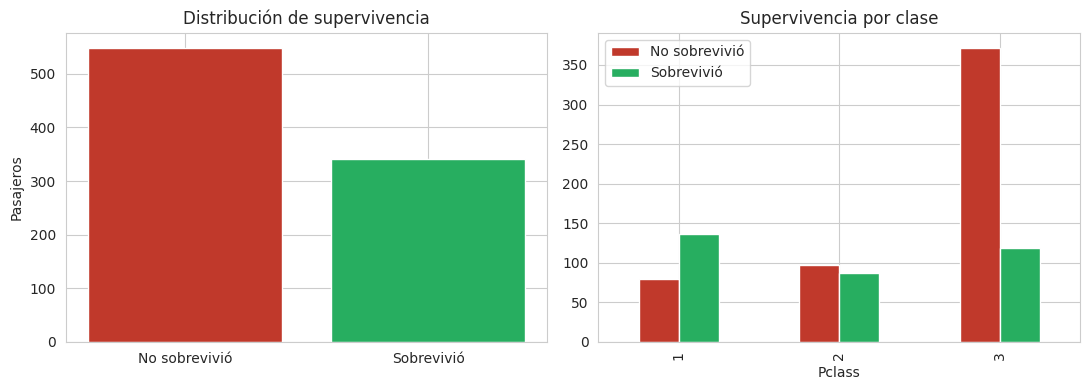

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

survived_counts = df['Survived'].value_counts()
axes[0].bar(['No sobrevivió', 'Sobrevivió'], survived_counts.values, color=['#c0392b', '#27ae60'])
axes[0].set_title('Distribución de supervivencia')
axes[0].set_ylabel('Pasajeros')

pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar', ax=axes[1], color=['#c0392b', '#27ae60'])
axes[1].set_title('Supervivencia por clase')
axes[1].set_xlabel('Pclass')
axes[1].legend(['No sobrevivió', 'Sobrevivió'])

plt.tight_layout()
plt.show()

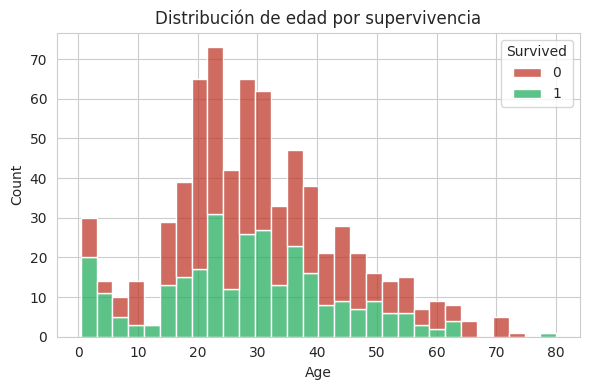

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=30, palette=['#c0392b', '#27ae60'], ax=ax)
ax.set_title('Distribución de edad por supervivencia')
plt.tight_layout()
plt.show()

In [ ]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print(survival_by_sex)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


## 4. Tratamiento de valores faltantes

In [ ]:
df_clean = handle_missing_values(df)
df_clean.isnull().sum().sort_values(ascending=False)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Cabin_known    0
dtype: int64

## 5. Ingeniería de variables

In [ ]:
df_features = engineer_features(df_clean)
df_features[['FamilySize', 'IsAlone', 'Title']].head()

,FamilySize,IsAlone,Title
0,2,0,Mr
1,2,0,Mrs
2,1,1,Miss
3,2,0,Mrs
4,1,1,Mr


In [ ]:
df_features['Title'].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64

## 6. Codificación de variables categóricas

In [ ]:
df_encoded = encode_categorical(df_features)
df_encoded.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,1,0,3,1,22.0,1,0,7.2500,0,2,0,False,True,False,True,False,False
1,2,1,1,0,38.0,1,0,71.2833,1,2,0,False,False,False,False,True,False
2,3,1,3,0,26.0,0,0,7.9250,0,1,1,False,True,True,False,False,False
3,4,1,1,0,35.0,1,0,53.1000,1,2,0,False,True,False,False,True,False
4,5,0,3,1,35.0,0,0,8.0500,0,1,1,False,True,False,True,False,False


## 7. Escalado de variables numéricas

In [ ]:
df_scaled = scale_numeric(df_encoded)
df_scaled[['Age', 'Fare', 'FamilySize']].describe()

,Age,Fare,FamilySize
count,8.910000e+02,8.910000e+02,8.910000e+02
mean,2.153160e-16,3.987333e-18,-2.392400e-17
std,1.000562e+00,1.000562e+00,1.000562e+00
min,-2.157819e+00,-6.484217e-01,-5.609748e-01
25%,-5.724938e-01,-4.891482e-01,-5.609748e-01
50%,-2.340704e-01,-3.573909e-01,-5.609748e-01
75%,5.179814e-01,-2.424635e-02,5.915988e-02
max,3.827009e+00,9.667167e+00,5.640372e+00


## 8. Exportación del dataset final

In [ ]:
df_scaled.to_csv('../data/titanic_processed.csv', index=False)
print(f"Dataset final: {df_scaled.shape[0]} filas, {df_scaled.shape[1]} columnas")
df_scaled.head()

Dataset final: 891 filas, 17 columnas


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin_known,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,1,0,3,1,-0.534891,1,0,-0.502445,0,0.059160,0,False,True,False,True,False,False
1,2,1,1,0,0.668392,1,0,0.786845,1,0.059160,0,False,False,False,False,True,False
2,3,1,3,0,-0.234070,0,0,-0.488854,0,-0.560975,1,False,True,True,False,False,False
3,4,1,1,0,0.442776,1,0,0.420730,1,0.059160,0,False,True,False,False,True,False
4,5,0,3,1,0.442776,0,0,-0.486337,0,-0.560975,1,False,True,False,True,False,False


## Conclusiones

- El dataset original presentaba valores faltantes principalmente en `Age` (~20%), `Cabin` (~77%) y `Embarked` (2 registros).
- La tasa de supervivencia fue notablemente mayor en mujeres y en pasajeros de primera clase.
- Se generaron variables derivadas (`FamilySize`, `IsAlone`, `Title`) que aportan información adicional para un futuro modelo predictivo.
- El dataset resultante (`titanic_processed.csv`) queda listo para ser utilizado en tareas de clasificación.